# 04 — Random-Projection LSH

`IndexLSH` projects each vector onto `nbits` random hyperplanes and stores the resulting
binary code.  Search is Hamming-distance then re-ranked.  Strong baseline for *low*
recall + *small* index size.  Curse of dimensionality at 2048 D is the main concern.

In [1]:
import os, sys, time, gc, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import faiss
import psutil
from tqdm import tqdm

sys.path.insert(0, str(Path.cwd()))
import utils

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

DATA = Path('data')
LAB_LIGHT = int(os.environ.get('LAB_LIGHT', '0'))
OUT_RUN = utils.run_mode()
RESULTS = utils.results_dir()
DOCS_IMG = utils.plots_dir()
print(f'OUT_RUN={OUT_RUN}  RESULTS={RESULTS}  DOCS_IMG={DOCS_IMG}')

# Load query + GT
with h5py.File(DATA / 'imagenet1m.h5', 'r') as h:
    queries = np.array(h['query'], dtype=np.float32)
    gt = np.array(h['groundtruth'], dtype=np.int32)
    DIM = int(h.attrs['dim']); N_BASE = int(h.attrs['n_base'])
    BASE_PATH = str(h.attrs['base_path'])

# Make BASE_PATH portable: prefer the file as it currently exists on disk
# (host path stored in h5 may not match container/CI paths).
_local = DATA / 'imagenet_base.fvecs'
if not Path(BASE_PATH).exists() and _local.exists():
    BASE_PATH = str(_local.resolve())
print('BASE_PATH =', BASE_PATH)

print('queries', queries.shape, 'gt', gt.shape, 'dim', DIM, 'base', N_BASE)
print(f"threads={faiss.omp_get_max_threads()}  RAM free={psutil.virtual_memory().available/1e9:.1f} GB")

OUT_RUN=full  RESULTS=results/full  DOCS_IMG=docs/img/full


BASE_PATH = data/imagenet_base.fvecs
queries (25000, 2048) gt (25000, 100) dim 2048 base 1281167
threads=8  RAM free=29.7 GB


In [2]:
N_SWEEP = int(os.environ.get('LAB_N_SWEEP', 500_000))
LAB_LIGHT = int(os.environ.get('LAB_LIGHT', '0'))
NBITS_GRID = [128, 256, 512, 1024, 2048, 4096]
QUERY_K = 100
if LAB_LIGHT:
    NBITS_GRID = [128, 256, 512, 1024]
QPS_REPEAT = int(os.environ.get('LAB_QPS_REPEAT', '2' if LAB_LIGHT else '1'))
QPS_WARMUP = int(os.environ.get('LAB_QPS_WARMUP', '1' if LAB_LIGHT else '0'))
_default_qn = queries.shape[0] if LAB_LIGHT else min(10000, queries.shape[0])
QUERY_N = int(os.environ.get('LAB_QUERY_N', str(_default_qn)))
queries_sweep = queries[:QUERY_N]
print(f"N_SWEEP={N_SWEEP:,}  LAB_LIGHT={LAB_LIGHT}  NBITS_GRID={NBITS_GRID}")
print(f"QPS_REPEAT={QPS_REPEAT}  QPS_WARMUP={QPS_WARMUP}  QUERY_N={QUERY_N}")

N_SWEEP=500,000  LAB_LIGHT=0  NBITS_GRID=[128, 256, 512, 1024, 2048, 4096]
QPS_REPEAT=3  QPS_WARMUP=1  QUERY_N=10000


In [3]:
def ensure_gt(n: int, k: int = QUERY_K):
    cache = DATA / f'gt_n{n}_k{k}.npy'
    if cache.exists():
        return np.load(cache)
    print(f'Computing exact GT (Flat) on first {n:,} base vectors × {queries.shape[0]:,} queries × k={k}...')
    flat = faiss.IndexFlatL2(DIM)
    utils.stream_add(flat, BASE_PATH, n)
    _, I = flat.search(queries, k)
    np.save(cache, I)
    del flat; gc.collect()
    return I

gt_local = ensure_gt(N_SWEEP)
train_x = utils.load_train_subset(BASE_PATH, min(200_000, N_SWEEP))
utils.print_mem('after GT + train_x')
print('train_x', train_x.shape, 'gt_local', gt_local.shape)

[mem after GT + train_x]  RSS=2.17 GB  ·  free=28.01 GB  ·  used%=14
train_x (200000, 2048) gt_local (25000, 100)


## LSH sweep — nbits grid

One `nbits` value per notebook cell (CSV checkpoint).

In [4]:
LSH_PATH = RESULTS / 'lsh.csv'
utils.init_results_csv(LSH_PATH)
print('LSH checkpoint:', LSH_PATH)

LSH checkpoint: results/full/lsh.csv


#### LSH — nbits=128

In [5]:
if 128 not in NBITS_GRID:
    print('skip LSH nbits=128')
else:
    idx = faiss.IndexLSH(DIM, 128)
    with utils.timed('train+add LSH 128', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
        lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
        repeat=QPS_REPEAT, warmup=QPS_WARMUP,
    )
    recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
    rows = [dict(algo='LSH', nbits=128,
               build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
               rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
               qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
               recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
               n_base=N_SWEEP)]
    utils.append_results(rows, LSH_PATH)
    del idx; gc.collect()
    print(f'[nbits={128:5}]  build {tb.elapsed:5.1f}s · QPS {qps:8.1f} · R@100 {recalls[100]:.3f}')

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:00<00:02,  3.64it/s]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:00<00:02,  3.71it/s]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:00<00:01,  3.74it/s]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:01<00:01,  3.76it/s]

...

add (n=500,000, batch=50,000):  70%|██████████████████████████████████████████████████████████████▎                          | 7/10 [00:01<00:00,  3.75it/s]

add (n=500,000, batch=50,000):  80%|███████████████████████████████████████████████████████████████████████▏                 | 8/10 [00:02<00:00,  3.75it/s]

add (n=500,000, batch=50,000):  90%|████████████████████████████████████████████████████████████████████████████████         | 9/10 [00:02<00:00,  3.76it/s]

add (n=500,000, batch=50,000): 100%|████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:02<00:00,  3.76it/s]

[nbits=  128]  build   2.8s · QPS  18004.7 · R@100 0.220


#### LSH — nbits=256

In [6]:
if 256 not in NBITS_GRID:
    print('skip LSH nbits=256')
else:
    idx = faiss.IndexLSH(DIM, 256)
    with utils.timed('train+add LSH 256', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
        lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
        repeat=QPS_REPEAT, warmup=QPS_WARMUP,
    )
    recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
    rows = [dict(algo='LSH', nbits=256,
               build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
               rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
               qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
               recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
               n_base=N_SWEEP)]
    utils.append_results(rows, LSH_PATH)
    del idx; gc.collect()
    print(f'[nbits={256:5}]  build {tb.elapsed:5.1f}s · QPS {qps:8.1f} · R@100 {recalls[100]:.3f}')

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:00<00:04,  2.16it/s]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:00<00:03,  2.18it/s]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:01<00:03,  2.19it/s]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:01<00:02,  2.19it/s]

...

add (n=500,000, batch=50,000):  70%|██████████████████████████████████████████████████████████████▎                          | 7/10 [00:03<00:01,  2.19it/s]

add (n=500,000, batch=50,000):  80%|███████████████████████████████████████████████████████████████████████▏                 | 8/10 [00:03<00:00,  2.19it/s]

add (n=500,000, batch=50,000):  90%|████████████████████████████████████████████████████████████████████████████████         | 9/10 [00:04<00:00,  2.20it/s]

add (n=500,000, batch=50,000): 100%|████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:04<00:00,  2.20it/s]

[nbits=  256]  build   4.7s · QPS  10604.6 · R@100 0.283


#### LSH — nbits=512

In [7]:
if 512 not in NBITS_GRID:
    print('skip LSH nbits=512')
else:
    idx = faiss.IndexLSH(DIM, 512)
    with utils.timed('train+add LSH 512', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
        lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
        repeat=QPS_REPEAT, warmup=QPS_WARMUP,
    )
    recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
    rows = [dict(algo='LSH', nbits=512,
               build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
               rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
               qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
               recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
               n_base=N_SWEEP)]
    utils.append_results(rows, LSH_PATH)
    del idx; gc.collect()
    print(f'[nbits={512:5}]  build {tb.elapsed:5.1f}s · QPS {qps:8.1f} · R@100 {recalls[100]:.3f}')

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:00<00:07,  1.19it/s]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:01<00:06,  1.20it/s]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:02<00:05,  1.20it/s]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:03<00:04,  1.20it/s]

...

add (n=500,000, batch=50,000):  70%|██████████████████████████████████████████████████████████████▎                          | 7/10 [00:05<00:02,  1.20it/s]

add (n=500,000, batch=50,000):  80%|███████████████████████████████████████████████████████████████████████▏                 | 8/10 [00:06<00:01,  1.20it/s]

add (n=500,000, batch=50,000):  90%|████████████████████████████████████████████████████████████████████████████████         | 9/10 [00:07<00:00,  1.20it/s]

add (n=500,000, batch=50,000): 100%|████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.20it/s]

[nbits=  512]  build   8.4s · QPS   5802.4 · R@100 0.342


#### LSH — nbits=1024

In [8]:
if 1024 not in NBITS_GRID:
    print('skip LSH nbits=1024')
else:
    idx = faiss.IndexLSH(DIM, 1024)
    with utils.timed('train+add LSH 1024', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
        lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
        repeat=QPS_REPEAT, warmup=QPS_WARMUP,
    )
    recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
    rows = [dict(algo='LSH', nbits=1024,
               build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
               rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
               qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
               recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
               n_base=N_SWEEP)]
    utils.append_results(rows, LSH_PATH)
    del idx; gc.collect()
    print(f'[nbits={1024:5}]  build {tb.elapsed:5.1f}s · QPS {qps:8.1f} · R@100 {recalls[100]:.3f}')

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:01<00:14,  1.58s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:03<00:12,  1.58s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:04<00:11,  1.58s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:06<00:09,  1.58s/it]

...

add (n=500,000, batch=50,000):  70%|██████████████████████████████████████████████████████████████▎                          | 7/10 [00:11<00:04,  1.59s/it]

add (n=500,000, batch=50,000):  80%|███████████████████████████████████████████████████████████████████████▏                 | 8/10 [00:12<00:03,  1.59s/it]

add (n=500,000, batch=50,000):  90%|████████████████████████████████████████████████████████████████████████████████         | 9/10 [00:14<00:01,  1.59s/it]

add (n=500,000, batch=50,000): 100%|████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:15<00:00,  1.58s/it]

[nbits= 1024]  build  16.0s · QPS   1651.8 · R@100 0.380


#### LSH — nbits=2048

In [9]:
if 2048 not in NBITS_GRID:
    print('skip LSH nbits=2048')
else:
    idx = faiss.IndexLSH(DIM, 2048)
    with utils.timed('train+add LSH 2048', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
        lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
        repeat=QPS_REPEAT, warmup=QPS_WARMUP,
    )
    recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
    rows = [dict(algo='LSH', nbits=2048,
               build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
               rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
               qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
               recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
               n_base=N_SWEEP)]
    utils.append_results(rows, LSH_PATH)
    del idx; gc.collect()
    print(f'[nbits={2048:5}]  build {tb.elapsed:5.1f}s · QPS {qps:8.1f} · R@100 {recalls[100]:.3f}')

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:03<00:27,  3.08s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:06<00:24,  3.08s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:09<00:21,  3.08s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:12<00:18,  3.08s/it]

...

add (n=500,000, batch=50,000):  70%|██████████████████████████████████████████████████████████████▎                          | 7/10 [00:21<00:09,  3.07s/it]

add (n=500,000, batch=50,000):  80%|███████████████████████████████████████████████████████████████████████▏                 | 8/10 [00:24<00:06,  3.07s/it]

add (n=500,000, batch=50,000):  90%|████████████████████████████████████████████████████████████████████████████████         | 9/10 [00:27<00:03,  3.07s/it]

add (n=500,000, batch=50,000): 100%|████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:30<00:00,  3.07s/it]

[nbits= 2048]  build  30.9s · QPS    972.3 · R@100 0.407


#### LSH — nbits=4096

In [10]:
if 4096 not in NBITS_GRID:
    print('skip LSH nbits=4096')
else:
    idx = faiss.IndexLSH(DIM, 4096)
    with utils.timed('train+add LSH 4096', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
        lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
        repeat=QPS_REPEAT, warmup=QPS_WARMUP,
    )
    recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
    rows = [dict(algo='LSH', nbits=4096,
               build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
               rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
               qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
               recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
               n_base=N_SWEEP)]
    utils.append_results(rows, LSH_PATH)
    del idx; gc.collect()
    print(f'[nbits={4096:5}]  build {tb.elapsed:5.1f}s · QPS {qps:8.1f} · R@100 {recalls[100]:.3f}')

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:06<00:54,  6.09s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:12<00:48,  6.09s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:18<00:42,  6.09s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:24<00:36,  6.09s/it]

...

add (n=500,000, batch=50,000):  70%|██████████████████████████████████████████████████████████████▎                          | 7/10 [00:42<00:18,  6.09s/it]

add (n=500,000, batch=50,000):  80%|███████████████████████████████████████████████████████████████████████▏                 | 8/10 [00:48<00:12,  6.09s/it]

add (n=500,000, batch=50,000):  90%|████████████████████████████████████████████████████████████████████████████████         | 9/10 [00:54<00:06,  6.09s/it]

add (n=500,000, batch=50,000): 100%|████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:00<00:00,  6.08s/it]

[nbits= 4096]  build  61.0s · QPS    516.6 · R@100 0.421


In [11]:
df_lsh = pd.read_csv(LSH_PATH)
try:
    del train_x
except NameError:
    pass
gc.collect()
utils.print_mem('after LSH sweep')
display(df_lsh)

[mem after LSH sweep]  RSS=0.66 GB  ·  free=29.56 GB  ·  used%=10


,algo,nbits,build_s,size_mb,rss_mb,rss_peak_mb,rss_delta_mb,faiss_threads,qps,latency_ms,latency_p99_ms,recall_1,recall_10,recall_100,n_base
0,LSH,128,2.773292,8.629483,2112.281250,6411.097656,43.101562,8,18004.742359,0.055792,0.059353,0.0572,0.11107,0.219976,500000
1,LSH,256,4.666987,17.258878,2120.886719,6468.535156,6.367188,8,10604.589560,0.094461,0.100873,0.0913,0.17052,0.283108,500000
2,LSH,512,8.423589,34.517667,2221.285156,6617.761719,99.796875,8,5802.360170,0.172555,0.191752,0.1531,0.23502,0.341713,500000
3,LSH,1024,15.954694,69.035245,2252.773438,6746.906250,62.308594,8,1651.819860,0.605644,0.692017,0.1983,0.28560,0.379922,500000
4,LSH,2048,30.853970,138.070401,2318.703125,7008.148438,128.199219,8,972.303409,1.030670,1.372667,0.2431,0.32265,0.407023,500000
5,LSH,4096,60.955238,276.140714,2503.375000,7583.445312,244.250000,8,516.598835,1.933675,2.215423,0.2695,0.34335,0.420694,500000


### Plot 1 — nbits vs Recall (R@1, R@10, R@100)

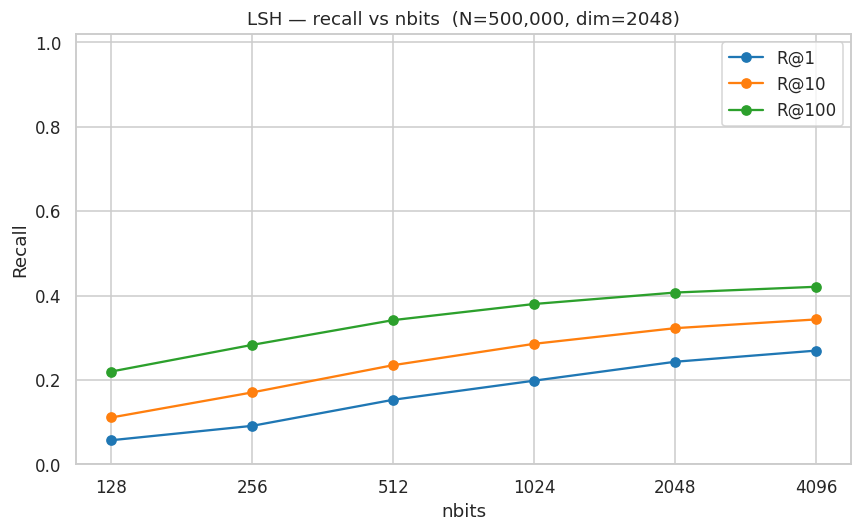

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for col, k in zip(['#1f77b4', '#ff7f0e', '#2ca02c'], [1, 10, 100]):
    ax.plot(df_lsh.nbits, df_lsh[f'recall_{k}'], marker='o', label=f'R@{k}', color=col)
ax.set_xscale('log'); ax.set_xlabel('nbits'); ax.set_ylabel('Recall')
ax.set_xticks(df_lsh.nbits)
ax.set_xticklabels([str(int(x)) for x in df_lsh.nbits])
ax.set_title(f'LSH — recall vs nbits  (N={N_SWEEP:,}, dim={DIM})')
ax.legend(); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig(DOCS_IMG / '04_lsh_recall.png', dpi=120); plt.show()

### Plot 2 — QPS vs nbits

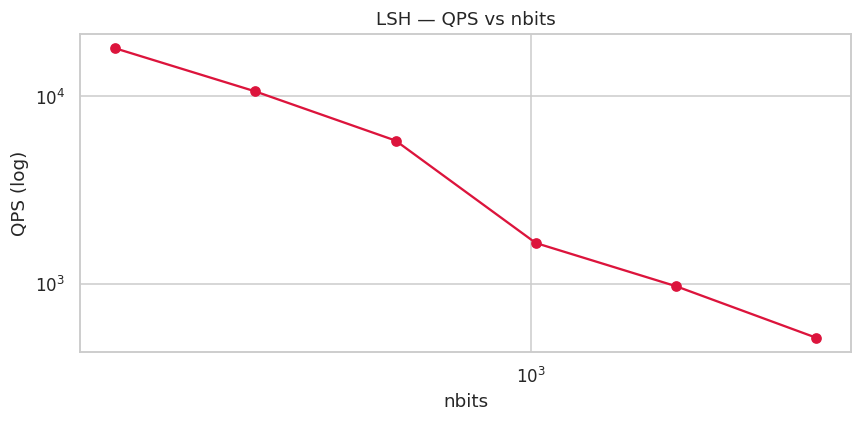

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_lsh.nbits, df_lsh.qps, marker='o', color='crimson')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('nbits'); ax.set_ylabel('QPS (log)')
ax.set_title('LSH — QPS vs nbits')
plt.tight_layout(); plt.savefig(DOCS_IMG / '04_lsh_qps.png', dpi=120); plt.show()

### Plot 3 — QPS vs Recall@100 Pareto

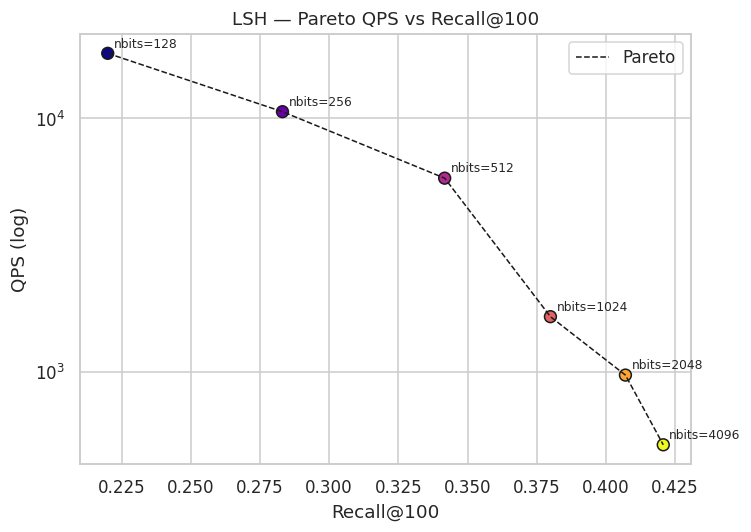

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_lsh.recall_100, df_lsh.qps, s=60, edgecolors='k', c=np.log2(df_lsh.nbits), cmap='plasma')
msk = utils.pareto_frontier(df_lsh.recall_100.values, df_lsh.qps.values)
o = np.argsort(df_lsh.recall_100.values[msk])
ax.plot(df_lsh.recall_100.values[msk][o], df_lsh.qps.values[msk][o], 'k--', lw=1, label='Pareto')
for i in np.where(msk)[0]:
    r = df_lsh.iloc[i]
    ax.annotate(f"nbits={int(r.nbits)}", (r.recall_100, r.qps),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_yscale('log'); ax.set_xlabel('Recall@100'); ax.set_ylabel('QPS (log)')
ax.set_title('LSH — Pareto QPS vs Recall@100')
ax.legend()
plt.tight_layout(); plt.savefig(DOCS_IMG / '04_lsh_pareto.png', dpi=120); plt.show()

### Plot 4 & 5 — Build time and index size vs nbits

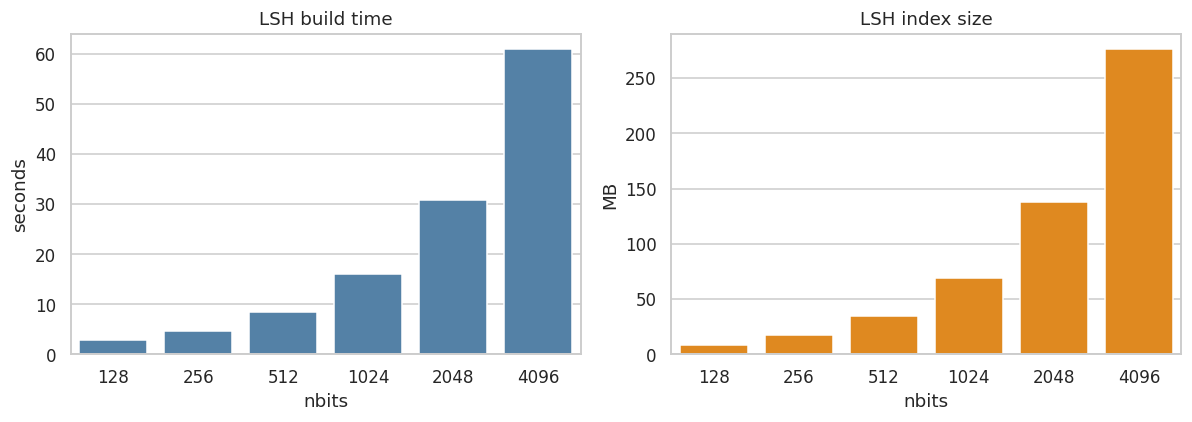

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=df_lsh, x='nbits', y='build_s', ax=ax[0], color='steelblue')
ax[0].set_title('LSH build time'); ax[0].set_ylabel('seconds')
sns.barplot(data=df_lsh, x='nbits', y='size_mb', ax=ax[1], color='darkorange')
ax[1].set_title('LSH index size'); ax[1].set_ylabel('MB')
plt.tight_layout(); plt.savefig(DOCS_IMG / '04_lsh_build_size.png', dpi=120); plt.show()

## Notes

* At 2048 D, LSH needs **a lot** of bits to start being competitive. We expect
  R@100 ≪ 0.5 even with 4096 bits — the curse of dimensionality bites hard.
* Despite poor recall, LSH index footprint is the smallest of the lot (just bit codes).
* Useful as a *very fast first-pass filter* but not as a stand-alone ANN solution at this
  dimensionality.